# Outsource-finetune — external-data transfer (APTOS-2019 → local) to lift rare grades

**Why:** every *in-distribution* lever (reweighting, focal, sampler, logit adjustment,
threshold tuning) capped 4-class **macro-sensitivity at ~0.765** (exp03, 5-fold CV pooled OOF,
95% CI 0.741–0.788). The binding constraint is data scarcity + low appearance diversity in the
rare grades (local train ≈ 142 R2 / 124 R3 *eyes*). No reweighting invents signal that isn't
there — so we add **real external information**.

**APTOS-2019** is a large public colour-fundus DR set graded ICDR 0–4. Mapped onto our NHS
4-class scheme (`build_aptos_imagefolder.py`), it adds **~1,192 R2 and ~295 R3 images** —
roughly 4× the R2 and 2× the R3 the local set has.

### Two-phase recipe (order matters)
| phase | data | init | loss | selects on |
|---|---|---|---|---|
| **1 — external pre-fine-tune** | APTOS train | RETFound DINOv2 (teacher) | weighted-CE | APTOS val macro-sens |
| **2 — local fine-tune** | LOCAL train | **Phase-1 checkpoint** | logit-adjusted (τ=1.0) | LOCAL val macro-sens |

Phase 1 teaches general DR features (incl. abundant R2/R3); Phase 2 domain-adapts to *your*
cameras/population. We fine-tune on local **after** APTOS so the external distribution doesn't
dominate — and we select/evaluate only on local data. The 4-way head transfers between phases
because `build_aptos_imagefolder.py` uses the SAME class indices as the local ImageFolder.

### Honest framing
This is a **single-split** run (fast, directional): does the APTOS init lift local test
macro-sensitivity above the ~0.715 single-split baseline / 0.765 CV ceiling? If yes, confirm
with 5-fold CV (Section C) before any claim — single-split macro-sens swings ~0.10 on this data.

### Laterality / data unchanged: OD=RE, OS=LE; local 8407 img / 3834 eyes / 2194 patients.

In [1]:
# --- ensure local Phases 0-3 + cache + RETFound repo + APTOS ImageFolder exist (skip if built) ---
import os, subprocess, sys
assert os.path.isdir("pipeline"), "Run from project root (Retfound.V2/)."
if not os.path.isdir("outputs/dr_imagefolder"):
    for s in ["build_manifest.py", "make_split.py", "materialize_imagefolder.py"]:
        print("running", s); subprocess.run([sys.executable, f"pipeline/{s}"], check=True)
if not os.path.isdir("outputs/dr_imagefolder_cache"):
    subprocess.run([sys.executable, "pipeline/build_resized_cache.py", "--size", "512"], check=True)
if not os.path.isdir("RETFound_repo"):
    subprocess.run(["git","clone","--depth","1","https://github.com/rmaphoh/RETFound.git","RETFound_repo"], check=True)
    subprocess.run([sys.executable,"-m","pip","install","-q","-r","RETFound_repo/requirements.txt"], check=True)
if not os.path.isdir("outputs/aptos_imagefolder"):
    print("materializing APTOS ImageFolder..."); subprocess.run([sys.executable, "pipeline/build_aptos_imagefolder.py"], check=True)
print("ready")

ready


In [2]:
# ============================ CONFIG ============================
BASE = dict(
    nb_classes = 4, input_size = 224,             # DINOv2 fixes img_size=224 (patch14)
    model = "RETFound_dinov2", model_arch = "dinov2_vitl14",
    finetune_id = "RETFound_dinov2_meh",          # GATED HF weights (checkpoint key: "teacher")
    drop_path = 0.2, adaptation = "finetune",
    batch_size = 8, accum_iter = 8,               # eff batch 64 (bs8 to fit 16GB safely)
    blr = 5e-3, layer_decay = 0.65, weight_decay = 0.05, min_lr = 1e-6, clip_grad = None,
    device = "cuda", seed = 42, num_workers = 10,
)
OUT = "outputs/outsource_finetune"; os.makedirs(OUT, exist_ok=True)
# phase 1: APTOS external pre-fine-tune
CFG_APTOS = dict(BASE, data_path="outputs/aptos_imagefolder", output_dir=f"{OUT}/phase1_aptos",
                 epochs=30, warmup_epochs=6, task="aptos_pretrain", loss="weighted_ce")
# phase 2: local fine-tune (logit-adjusted, our validated recipe)
CFG_LOCAL = dict(BASE, data_path="outputs/dr_imagefolder_cache", output_dir=OUT,
                 epochs=50, warmup_epochs=10, task="local_finetune", loss="logit_adjusted", la_tau=1.0)
SELECTION_METRIC = "macro_sensitivity"
import os
for c in (CFG_APTOS, CFG_LOCAL): os.makedirs(c["output_dir"], exist_ok=True)
print("phase1 (APTOS):", CFG_APTOS["output_dir"], "| phase2 (local):", CFG_LOCAL["output_dir"])

phase1 (APTOS): outputs/outsource_finetune/phase1_aptos | phase2 (local): outputs/outsource_finetune


In [3]:
# ============================ imports, seeds, device + shared trainer ============================
import os, sys, json, time, copy
import numpy as np, torch
sys.path.insert(0, "pipeline"); sys.path.insert(0, "RETFound_repo")
import dr_train as T, dr_eval as E
from dr_losses import LogitAdjustedLoss
from engine_finetune import train_one_epoch
from sklearn.metrics import roc_auc_score

T.set_seed(BASE["seed"]); torch.backends.cudnn.benchmark = True
device = torch.device(BASE["device"] if torch.cuda.is_available() else "cpu")
print("device:", device, "| backbone:", BASE["model"])

def make_criterion(cfg, ds_tr):
    counts = np.bincount(np.array(ds_tr.targets), minlength=cfg["nb_classes"])
    if cfg["loss"] == "logit_adjusted":
        return LogitAdjustedLoss(counts, tau=cfg.get("la_tau", 1.0)), counts   # raw logits at inference
    cw, _ = T.class_weights_from_dataset(ds_tr, cfg["nb_classes"], device)      # weighted CE
    return torch.nn.CrossEntropyLoss(weight=cw), counts

def val_scores(model, dl_va):
    y, p = E.predict(model, dl_va, device); pred = p.argmax(1)
    try:
        yoh = np.eye(BASE["nb_classes"])[y]; cols=[c for c in range(BASE["nb_classes"]) if yoh[:,c].sum()>0]
        auroc = roc_auc_score(yoh[:,cols], p[:,cols], average="macro", multi_class="ovr")
    except Exception: auroc = float("nan")
    msens, mspec = E.macro_sens_spec(y, pred)
    return float(auroc), msens, mspec

def train_phase(model, cfg, dl_tr, dl_va, criterion, tag):
    args = T.make_args(cfg)                            # ONE args: build_optimizer sets args.lr on it
    optimizer, scaler = T.build_optimizer(model, args) # (make_args leaves lr=None until here)
    best, best_ep, hist = -1.0, -1, []
    ckpt = os.path.join(cfg["output_dir"], "checkpoint-best.pth"); t0 = time.time()
    for epoch in range(cfg["epochs"]):
        tr = train_one_epoch(model, criterion, dl_tr, optimizer, device, epoch, scaler,
                             args.clip_grad, None, None, args)
        auroc, msens, mspec = val_scores(model, dl_va)
        hist.append({"epoch": epoch, "train_loss": tr["loss"], "val_macro_auroc": auroc,
                     "val_macro_sensitivity": msens, "val_macro_specificity": mspec})
        flag = ""
        if msens > best:
            best, best_ep = msens, epoch
            torch.save({"model": copy.deepcopy(model.state_dict()), "epoch": epoch, "config": cfg,
                        "val_macro_sensitivity": msens, "val_macro_specificity": mspec,
                        "val_macro_auroc": auroc}, ckpt); flag = "  <-- best"
        print(f"[{tag}] ep {epoch:02d} loss={tr['loss']:.4f} val_mSens={msens:.4f} "
              f"val_mSpec={mspec:.4f} val_AUROC={auroc:.4f}{flag}")
    json.dump(hist, open(os.path.join(cfg["output_dir"], "history.json"), "w"), indent=2)
    print(f"[{tag}] done in {(time.time()-t0)/60:.1f} min | best epoch {best_ep} val_mSens={best:.4f}")
    return ckpt, hist

/home/eth/miniforge3/envs/retfound/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | backbone: RETFound_dinov2


## Phase 1 — pre-fine-tune on APTOS-2019 (external)
Starts from RETFound DINOv2 teacher weights, learns general DR features from the large public
set (abundant R2/R3), selected on APTOS val macro-sensitivity. ~30 epochs on 2,930 images.

In [4]:
# ---- Phase 1 data + model + train ----
args_a = T.make_args(CFG_APTOS)
(a_tr, a_va, a_te), (adl_tr, adl_va, adl_te) = T.build_loaders(args_a, shuffle_train=True)
print("APTOS images train/val/test:", len(a_tr), len(a_va), len(a_te))
assert a_tr.class_to_idx == json.load(open("outputs/class_mapping.json"))["ordinal_class_to_index"], \
    "APTOS class indices must match local"

model = T.build_model_arch(args_a); msg = T.load_pretrained(model, args_a); model.to(device)
print("missing keys (expect head.* only):", list(msg.missing_keys))
crit_a, counts_a = make_criterion(CFG_APTOS, a_tr)
print("APTOS train class counts:", counts_a)
phase1_ckpt, _ = train_phase(model, CFG_APTOS, adl_tr, adl_va, crit_a, "APTOS")

APTOS images train/val/test: 2930 366 366


/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_train.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


Position interpolate from 37x37 to 16x16
missing keys (expect head.* only): ['head.weight', 'head.bias']
APTOS train class counts: [1434  300  962  234]


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()
/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/366]  eta: 0:07:14  lr: 0.000000  loss: 1.3867 (1.3867)  time: 1.1864  data: 0.6896  max mem: 3737
Epoch: [0]  [ 20/366]  eta: 0:01:14  lr: 0.000009  loss: 1.3862 (1.3864)  time: 0.1665  data: 0.0001  max mem: 7207
Epoch: [0]  [ 40/366]  eta: 0:01:02  lr: 0.000023  loss: 1.3852 (1.3858)  time: 0.1679  data: 0.0001  max mem: 7207
Epoch: [0]  [ 60/366]  eta: 0:00:55  lr: 0.000032  loss: 1.3811 (1.3841)  time: 0.1636  data: 0.0001  max mem: 7207
Epoch: [0]  [ 80/366]  eta: 0:00:51  lr: 0.000046  loss: 1.3817 (1.3828)  time: 0.1681  data: 0.0001  max mem: 7207
Epoch: [0]  [100/366]  eta: 0:00:46  lr: 0.000055  loss: 1.3755 (1.3809)  time: 0.1649  data: 0.0001  max mem: 7207
Epoch: [0]  [120/366]  eta: 0:00:43  lr: 0.000068  loss: 1.3713 (1.3791)  time: 0.1688  data: 0.0001  max mem: 7207
Epoch: [0]  [140/366]  eta: 0:00:39  lr: 0.000077  loss: 1.3294 (1.3730)  time: 0.1659  data: 0.0001  max mem: 7207
Epoch: [0]  [160/366]  eta: 0:00:35  lr: 0.000091  loss: 1.3411 (1.3687)

...

[APTOS] ep 28 loss=0.3924 val_mSens=0.7801 val_mSpec=0.9578 val_AUROC=0.9514


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [29]  [  0/366]  eta: 0:05:10  lr: 0.000006  loss: 0.1798 (0.1798)  time: 0.8480  data: 0.6933  max mem: 7207
Epoch: [29]  [ 20/366]  eta: 0:01:09  lr: 0.000006  loss: 0.2155 (0.2986)  time: 0.1676  data: 0.0002  max mem: 7207
Epoch: [29]  [ 40/366]  eta: 0:01:00  lr: 0.000005  loss: 0.5193 (0.4180)  time: 0.1714  data: 0.0002  max mem: 7207
Epoch: [29]  [ 60/366]  eta: 0:00:55  lr: 0.000005  loss: 0.2300 (0.4091)  time: 0.1676  data: 0.0001  max mem: 7207
Epoch: [29]  [ 80/366]  eta: 0:00:50  lr: 0.000004  loss: 0.3023 (0.3990)  time: 0.1711  data: 0.0001  max mem: 7207
Epoch: [29]  [100/366]  eta: 0:00:46  lr: 0.000004  loss: 0.4212 (0.4113)  time: 0.1679  data: 0.0001  max mem: 7207
Epoch: [29]  [120/366]  eta: 0:00:43  lr: 0.000003  loss: 0.1993 (0.3929)  time: 0.1718  data: 0.0002  max mem: 7207
Epoch: [29]  [140/366]  eta: 0:00:39  lr: 0.000003  loss: 0.3223 (0.3859)  time: 0.1682  data: 0.0001  max mem: 7207
Epoch: [29]  [160/366]  eta: 0:00:35  lr: 0.000003  loss: 0.2270

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


[APTOS] ep 29 loss=0.3709 val_mSens=0.7801 val_mSpec=0.9578 val_AUROC=0.9513
[APTOS] done in 33.8 min | best epoch 18 val_mSens=0.8316


## Phase 2 — fine-tune on the LOCAL set
Initialise from the Phase-1 checkpoint (features + 4-way head already DR-aware), then
domain-adapt to the local cameras/population with the logit-adjusted loss, selected on LOCAL
val macro-sensitivity.

In [5]:
# ---- Phase 2 data + init from Phase 1 + train ----
args_l = T.make_args(CFG_LOCAL)
(l_tr, l_va, l_te), (ldl_tr, ldl_va, ldl_te) = T.build_loaders(args_l, shuffle_train=True)
print("LOCAL images train/val/test:", len(l_tr), len(l_va), len(l_te))

model = T.build_model_arch(args_l)                       # fresh DINOv2 arch
sd = torch.load(phase1_ckpt, map_location="cpu")["model"]
miss, unexp = model.load_state_dict(sd, strict=False)    # head shapes match -> transfers too
model.to(device)
print(f"loaded Phase-1 weights | missing={len(miss)} unexpected={len(unexp)}")
crit_l, counts_l = make_criterion(CFG_LOCAL, l_tr)
print("LOCAL train class counts:", counts_l, "| loss:", CFG_LOCAL["loss"], "tau", CFG_LOCAL.get("la_tau"))
local_ckpt, hist_l = train_phase(model, CFG_LOCAL, ldl_tr, ldl_va, crit_l, "LOCAL")

LOCAL images train/val/test: 5853 1268 1286


/tmp/ipykernel_839013/766564135.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(phase1_ckpt, map_location="cpu")["model"]


loaded Phase-1 weights | missing=0 unexpected=0
LOCAL train class counts: [3369 1909  299  276] | loss: logit_adjusted tau 1.0


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()
/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/731]  eta: 0:07:55  lr: 0.000000  loss: 1.5886 (1.5886)  time: 0.6498  data: 0.4984  max mem: 7207
Epoch: [0]  [ 20/731]  eta: 0:02:15  lr: 0.000003  loss: 0.8323 (1.3122)  time: 0.1679  data: 0.0001  max mem: 7207
Epoch: [0]  [ 40/731]  eta: 0:02:04  lr: 0.000007  loss: 1.0551 (1.3211)  time: 0.1676  data: 0.0001  max mem: 7207
Epoch: [0]  [ 60/731]  eta: 0:01:57  lr: 0.000010  loss: 1.2454 (1.3460)  time: 0.1664  data: 0.0001  max mem: 7207
Epoch: [0]  [ 80/731]  eta: 0:01:53  lr: 0.000014  loss: 1.5995 (1.3969)  time: 0.1704  data: 0.0001  max mem: 7207
Epoch: [0]  [100/731]  eta: 0:01:48  lr: 0.000016  loss: 1.0158 (1.3849)  time: 0.1633  data: 0.0001  max mem: 7207
Epoch: [0]  [120/731]  eta: 0:01:44  lr: 0.000021  loss: 1.5539 (1.3846)  time: 0.1707  data: 0.0001  max mem: 7207
Epoch: [0]  [140/731]  eta: 0:01:41  lr: 0.000023  loss: 1.0925 (1.3674)  time: 0.1673  data: 0.0001  max mem: 7207
Epoch: [0]  [160/731]  eta: 0:01:37  lr: 0.000027  loss: 1.0581 (1.3379)

...

[LOCAL] ep 48 loss=0.2882 val_mSens=0.7127 val_mSpec=0.9164 val_AUROC=0.9108


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [49]  [  0/731]  eta: 0:07:29  lr: 0.000003  loss: 0.5387 (0.5387)  time: 0.6145  data: 0.4551  max mem: 7207
Epoch: [49]  [ 20/731]  eta: 0:02:14  lr: 0.000003  loss: 0.2171 (0.3178)  time: 0.1684  data: 0.0001  max mem: 7207
Epoch: [49]  [ 40/731]  eta: 0:02:04  lr: 0.000003  loss: 0.2351 (0.3200)  time: 0.1717  data: 0.0001  max mem: 7207
Epoch: [49]  [ 60/731]  eta: 0:01:58  lr: 0.000003  loss: 0.1877 (0.3117)  time: 0.1684  data: 0.0001  max mem: 7207
Epoch: [49]  [ 80/731]  eta: 0:01:54  lr: 0.000003  loss: 0.2287 (0.2993)  time: 0.1719  data: 0.0001  max mem: 7207
Epoch: [49]  [100/731]  eta: 0:01:49  lr: 0.000002  loss: 0.2121 (0.2929)  time: 0.1683  data: 0.0001  max mem: 7207
Epoch: [49]  [120/731]  eta: 0:01:46  lr: 0.000002  loss: 0.2342 (0.2797)  time: 0.1719  data: 0.0001  max mem: 7207
Epoch: [49]  [140/731]  eta: 0:01:42  lr: 0.000002  loss: 0.2018 (0.2844)  time: 0.1685  data: 0.0001  max mem: 7207
Epoch: [49]  [160/731]  eta: 0:01:38  lr: 0.000002  loss: 0.2146

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


[LOCAL] ep 49 loss=0.2708 val_mSens=0.7120 val_mSpec=0.9157 val_AUROC=0.9107
[LOCAL] done in 111.2 min | best epoch 5 val_mSens=0.7880


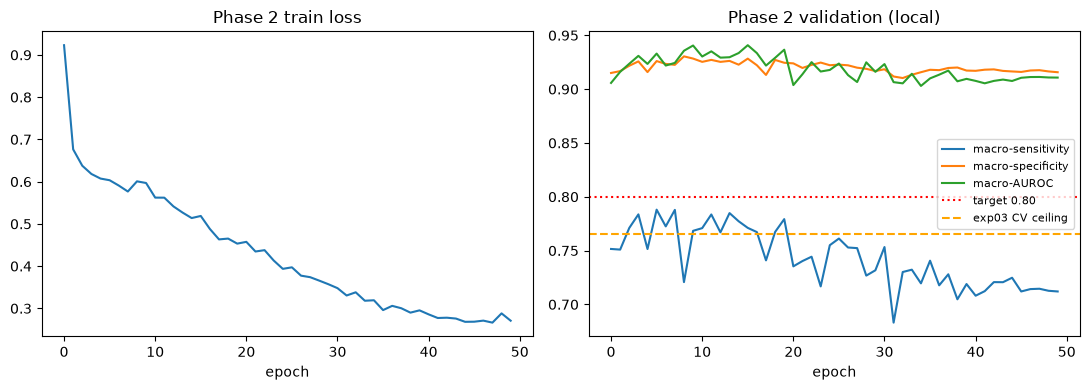

In [6]:
# ---- training curves (Phase 2) ----
import matplotlib.pyplot as plt
ep = [x["epoch"] for x in hist_l]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [x["train_loss"] for x in hist_l]); ax[0].set_title("Phase 2 train loss"); ax[0].set_xlabel("epoch")
for k, lab in [("val_macro_sensitivity","macro-sensitivity"),
               ("val_macro_specificity","macro-specificity"),("val_macro_auroc","macro-AUROC")]:
    ax[1].plot(ep, [x[k] for x in hist_l], label=lab)
ax[1].axhline(0.80, ls=":", c="red", label="target 0.80")
ax[1].axhline(0.765, ls="--", c="orange", label="exp03 CV ceiling")
ax[1].legend(fontsize=8); ax[1].set_title("Phase 2 validation (local)"); ax[1].set_xlabel("epoch")
fig.tight_layout(); plt.show()

## Evaluate on the LOCAL test set + compare to the ceiling
Eye-level macro-sensitivity with TTA, vs the exp03 in-distribution ceiling (pooled-OOF 0.765).

In [7]:
# ---- LOCAL test (best Phase-2 checkpoint) ----
best = torch.load(local_ckpt, map_location="cpu")
model.load_state_dict(best["model"]); model.to(device)
test_paths = [p for p, _ in l_te.samples]
y_true, y_prob = E.predict(model, ldl_te, device, tta=["identity","hflip","vflip","hvflip"])
rep = E.full_report(test_paths, y_true, y_prob, os.path.join(OUT, "eval_test"))
r = rep["eye_level"]; b = r["binary_referable"]
print(f"EYE-LEVEL (n={r['n']}): MACRO-SENS={r['macro_sensitivity']:.4f}  "
      f"mSpec={r['macro_specificity']:.4f}  macroAUROC={r['macro_auroc_ovr']:.4f}")
print("per-class sens:", {['R0','R1','R2','R3'][k]: round(v['sensitivity'],3) for k,v in r['per_class'].items()})
print(f"referable(R2+): AUROC={b['auroc']:.4f} sens={b['sensitivity']:.3f} spec={b['specificity']:.3f}")
print("\ncompare (eye-level test macro-sens):")
print(f"  DINOv2 logit-adj, NO APTOS (exp03 single-split): 0.715   | exp03 5-fold CV pooled: 0.765")
print(f"  DINOv2 logit-adj, + APTOS  (this run)          : {r['macro_sensitivity']:.3f}")
print("\n⚠️  single split — swings ~0.10. If this beats 0.765, confirm with Section C (5-fold CV).")

/tmp/ipykernel_839013/90975766.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(local_ckpt, map_location="cpu")
/home/eth/Desktop/isaack/Retfound.V2/pip

EYE-LEVEL (n=584): MACRO-SENS=0.6942  mSpec=0.9201  macroAUROC=0.9348
per-class sens: {'R0': 0.925, 'R1': 0.655, 'R2': 0.743, 'R3': 0.455}
referable(R2+): AUROC=0.9814 sens=0.930 spec=0.945

compare (eye-level test macro-sens):
  DINOv2 logit-adj, NO APTOS (exp03 single-split): 0.715   | exp03 5-fold CV pooled: 0.765
  DINOv2 logit-adj, + APTOS  (this run)          : 0.694

⚠️  single split — swings ~0.10. If this beats 0.765, confirm with Section C (5-fold CV).


## Section C — confirm with 5-fold CV (only if Section A/B beat the ceiling)
The single-split number above is directional. To make a defensible claim, repeat the *local*
phase under 5-fold CV, initialising every fold from the **same** Phase-1 APTOS checkpoint
(Phase 1 is domain-external, so it need not be refit per fold — reuse `phase1_ckpt`).

`run_cv.py` supports an external-init via `--init-ckpt`; run:
```bash
python pipeline/run_cv.py --kfolds 5 --backbone dinov2 --loss logit_adjusted --la-tau 1.0 \
    --batch-size 8 --accum-iter 8 --epochs 50 --tta identity,hflip,vflip,hvflip \
    --init-ckpt outputs/outsource_finetune/phase1_aptos/checkpoint-best.pth
```
Then read `outputs/cv/cv_results.json` -> `pooled_oof.macro_sensitivity` and its 95% CI, exactly
as in exp03. A stable win means the pooled lower-CI bound clears 0.765 (and ideally 0.80).

## Notes
- **Domain shift is the risk.** APTOS uses different cameras/populations; that's why we fine-tune
  on local *after* (Phase 2) and select/evaluate only on local. If Phase 2 val macro-sens starts
  *below* the from-scratch run, the APTOS init hurt — lower `CFG_APTOS['epochs']` (less external
  overfit) or reduce Phase-2 `blr` (gentler adaptation).
- **R1 is the true floor** (0.612 pooled): APTOS adds R1 too (~340 imgs), but if R1 stays low,
  an ordinal-aware loss (adjacent-grade penalty) is the complementary next lever.
- APTOS grades are ICDR (severe NPDR=3 folded into R2); a handful of severe cases may look unlike
  local R2 — acceptable noise for a pretraining phase.